# Sistema Inteligente de Recomendación Alimenticia

**Curso:** Inteligencia Artificial — Principios y Técnicas (ISIA-108)  
**Universidad:** UPAO — Semestre 2026-10  

Este notebook ejecuta el sistema completo desde Google Colab.  
Para versión modular en VS Code, ver el repositorio `proyecto_ia/`.

---
## Arquitectura

| Capa | Técnica |
|---|---|
| 1 | Cálculo nutricional (Mifflin-St Jeor) |
| 2 | Sistema Experto |
| 3 | K-Means |
| 4 | Optimización con PuLP |
| 5 | LLM (Gemini API) — Nombrado de platillos |

---

## Resumen de reglas del sistema

| Tipo | Cantidad | Ubicación |
|---|---|---|
| Salud | 4 | Sistema Experto (Grupo A) |
| Contexto | 3 | Sistema Experto (Grupo B) |
| Estructura | 4 | Optimizador PuLP |
| Macros | 3 | Celda 5 |
| Seguridad | 1 | Celda 5 |
| **Total activas** | **15** | |

## Celda 1 — Setup del entorno

Configura el entorno de trabajo instalando las librerías necesarias, importando los módulos y montando Google Drive para acceder a los datos.

In [1]:
# Instalación de librerías necesarias
!pip install -q pulp

# Imports principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 30)

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('✓ Entorno listo')

Mounted at /content/drive
✓ Entorno listo


## Celda 2 — Carga del dataset

Carga el archivo CSV con los 81 ingredientes desde Google Drive, elimina las columnas no utilizadas y realiza validaciones básicas de integridad.

In [2]:
# Ruta al dataset en tu Drive
RUTA_DATASET = '/content/drive/MyDrive/proyecto_ia/ingredientes_dataset.csv'

df_ingredientes = pd.read_csv(RUTA_DATASET, encoding='utf-8-sig')

# Eliminar columnas de dietas especiales (vegano/vegetariano)
columnas_a_eliminar = ['apto_vegetariano', 'apto_vegano']
df_ingredientes = df_ingredientes.drop(columns=[col for col in columnas_a_eliminar if col in df_ingredientes.columns])

# Validaciones rápidas
assert len(df_ingredientes) > 0
assert 'calorias' in df_ingredientes.columns
assert df_ingredientes['id'].is_unique

print(f'✓ Dataset cargado: {len(df_ingredientes)} ingredientes, {df_ingredientes.shape[1]} columnas')
df_ingredientes.head()

✓ Dataset cargado: 81 ingredientes, 18 columnas


,id,nombre,nombre_en,categoria,estado,tipo_uso,grupo_intercambiable,calorias,proteina_g,carbohidratos_g,grasa_g,fibra_g,azucar_g,grasa_saturada_g,sodio_mg,indice_glucemico,tipo_proteina,comidas_recomendadas
0,1,Pollo,Chicken breast (cooked),Proteina,cocido,principal,ave,220,41.3,0.0,4.8,0.0,0.0,1.3,99,ninguno,animal,"desayuno,almuerzo,cena"
1,2,Pavo,Turkey breast (cooked),Proteina,cocido,principal,ave,180,40.0,0.0,1.3,0.0,0.0,0.4,133,ninguno,animal,"desayuno,almuerzo,cena"
2,3,Carne molida,Ground beef 80/20 (cooked),Proteina,cocido,principal,carne_roja,290,26.5,0.0,20.0,0.0,0.0,7.7,75,ninguno,animal,"almuerzo,cena"
3,4,Bistec,Beef sirloin steak (cooked),Proteina,cocido,principal,carne_roja,222,31.0,0.0,10.6,0.0,0.0,4.1,60,ninguno,animal,"almuerzo,cena"
4,5,Lomo de res,Beef tenderloin (cooked),Proteina,cocido,principal,carne_roja,247,30.0,0.0,13.2,0.0,0.0,5.0,55,ninguno,animal,"almuerzo,cena"


## Celda 3 — Análisis exploratorio (EDA)

Muestra la distribución de ingredientes por categoría y por índice glucémico mediante gráficos de barras para entender la composición del dataset.

Distribución por categoría:
categoria
Carbohidrato    19
Fruta           17
Proteina        14
Verdura         12
Grasa            7
Condimento       5
Lacteo           4
Bebida           3
Name: count, dtype: int64


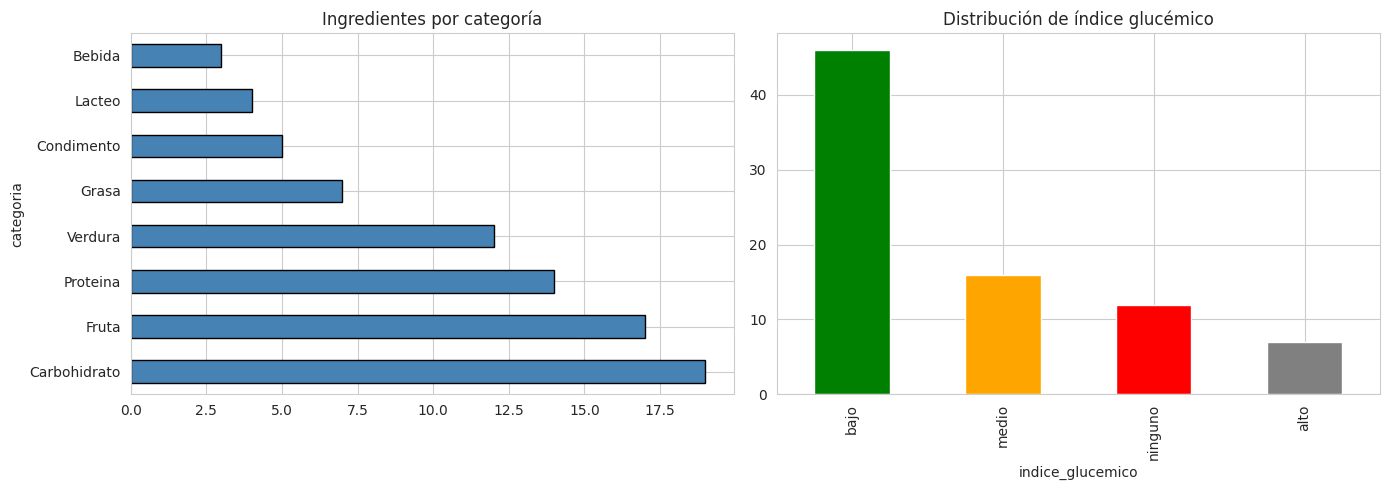

In [3]:
# Información estructural
print('Distribución por categoría:')
print(df_ingredientes['categoria'].value_counts())

# Visualización rápida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_ingredientes['categoria'].value_counts().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Ingredientes por categoría')
df_ingredientes['indice_glucemico'].value_counts().plot(
    kind='bar', ax=axes[1], color=['green', 'orange', 'red', 'gray'])
axes[1].set_title('Distribución de índice glucémico')
plt.tight_layout()
plt.show()

## Celda 4 — Cálculo nutricional

Implementa la ecuación de Mifflin-St Jeor para calcular la Tasa Metabólica Basal (TMB) y el Gasto Energético Total (GET) según el nivel de actividad física.



In [4]:
# Factores de actividad física
FACTORES_ACTIVIDAD = {
    'sedentario':  1.20, 'ligero': 1.375, 'moderado': 1.55,
    'intenso':     1.725, 'muy_intenso': 1.90,
}

def calcular_tmb(peso_kg, altura_cm, edad, sexo):
    """TMB con Mifflin-St Jeor."""
    if sexo.upper() == 'M':
        return 10 * peso_kg + 6.25 * altura_cm - 5 * edad + 5
    elif sexo.upper() == 'F':
        return 10 * peso_kg + 6.25 * altura_cm - 5 * edad - 161
    raise ValueError(f"Sexo debe ser 'M' o 'F': {sexo}")

def calcular_get(tmb, nivel_actividad):
    """GET = TMB × factor de actividad."""
    return tmb * FACTORES_ACTIVIDAD[nivel_actividad]

# Prueba
tmb_test = calcular_tmb(75, 175, 25, 'M')
print(f'TMB: {tmb_test:.0f} | GET: {calcular_get(tmb_test, "moderado"):.0f}')

TMB: 1724 | GET: 2672


## Celda 5 — Reparto de macros (Reglas B1, B2, B3 + F1)

Define las reglas para distribuir calorías y macronutrientes (proteínas, carbohidratos, grasas) según el objetivo del usuario: perder grasa, mantener peso o ganar músculo.



In [5]:
# Macros según objetivo
REGLAS_OBJETIVO = {
    'perder_grasa':  {'ajuste_calorico': 0.80, 'pct_proteina': 0.40, 'pct_carbos': 0.35, 'pct_grasa': 0.25},
    'mantener':      {'ajuste_calorico': 1.00, 'pct_proteina': 0.30, 'pct_carbos': 0.45, 'pct_grasa': 0.25},
    'ganar_musculo': {'ajuste_calorico': 1.15, 'pct_proteina': 0.35, 'pct_carbos': 0.40, 'pct_grasa': 0.25},
}

# Distribución de calorías entre comidas
DISTRIBUCION_POR_OBJETIVO = {
    'perder_grasa':  {'desayuno': 0.25, 'almuerzo': 0.35, 'cena': 0.30, 'snack': 0.10},
    'mantener':      {'desayuno': 0.25, 'almuerzo': 0.30, 'cena': 0.30, 'snack': 0.15},
    'ganar_musculo': {'desayuno': 0.22, 'almuerzo': 0.33, 'cena': 0.30, 'snack': 0.15},
}

KCAL_POR_GRAMO = {'proteina': 4, 'carbos': 4, 'grasa': 9}

# Mínimo calórico de seguridad
MINIMO_KCAL_SEGURIDAD = {'M': 1500, 'F': 1200}

def calcular_targets_diarios(get, objetivo, sexo='M'):
    """Calcula calorías y macros."""
    regla = REGLAS_OBJETIVO[objetivo]
    cal_calc = get * regla['ajuste_calorico']
    minimo = MINIMO_KCAL_SEGURIDAD.get(sexo.upper(), 1200)
    advertencia = cal_calc < minimo
    cal_final = max(cal_calc, minimo)
    return {
        'calorias_objetivo':            round(cal_final),
        'calorias_calculadas':          round(cal_calc),
        'proteina_g': round(cal_final * regla['pct_proteina'] / 4),
        'carbos_g':   round(cal_final * regla['pct_carbos']   / 4),
        'grasa_g':    round(cal_final * regla['pct_grasa']    / 9),
        'objetivo':                     objetivo,
        'advertencia_minimo_seguridad': advertencia,
    }

def repartir_por_comida(targets):
    """Reparte targets entre las 4 comidas según el objetivo."""
    distribucion = DISTRIBUCION_POR_OBJETIVO[targets['objetivo']]
    return {
        c: {
            'calorias_objetivo': round(targets['calorias_objetivo'] * f),
            'proteina_g':        round(targets['proteina_g'] * f),
            'carbos_g':          round(targets['carbos_g'] * f),
            'grasa_g':           round(targets['grasa_g'] * f),
        } for c, f in distribucion.items()
    }

print('✓ Reparto de macros listo')

✓ Reparto de macros listo


## Celda 6 — Perfil del usuario

Define la clase PerfilUsuario que valida y encapsula los datos antropométricos del usuario, además de calcular sus requerimientos nutricionales personalizados.



In [6]:
class PerfilUsuario:
    """Datos del usuario."""

    OPCIONES_VALIDAS = {
        'sexo':            ['M', 'F'],
        'nivel_actividad': list(FACTORES_ACTIVIDAD.keys()),
        'objetivo':        list(REGLAS_OBJETIVO.keys()),
    }

    def __init__(self, edad, sexo, peso_kg, altura_cm, nivel_actividad, objetivo):
        # Validaciones de rango
        if not (10 <= edad <= 100): raise ValueError(f'Edad fuera de rango: {edad}')
        if not (30 <= peso_kg <= 250): raise ValueError(f'Peso fuera de rango: {peso_kg}')
        if not (100 <= altura_cm <= 230): raise ValueError(f'Altura fuera de rango: {altura_cm}')
        for campo, opciones in self.OPCIONES_VALIDAS.items():
            if locals()[campo] not in opciones:
                raise ValueError(f"'{campo}' inválido")
        self.edad, self.sexo = edad, sexo.upper()
        self.peso_kg, self.altura_cm = peso_kg, altura_cm
        self.nivel_actividad = nivel_actividad
        self.objetivo = objetivo

    def calcular_targets(self):
        tmb = calcular_tmb(self.peso_kg, self.altura_cm, self.edad, self.sexo)
        get = calcular_get(tmb, self.nivel_actividad)
        targets = calcular_targets_diarios(get, self.objetivo, sexo=self.sexo)
        targets['tmb'], targets['get'] = round(tmb), round(get)
        return targets

    def __repr__(self):
        return (f'PerfilUsuario(edad={self.edad}, sexo={self.sexo}, '
                f'{self.peso_kg}kg, {self.altura_cm}cm, '
                f'actividad={self.nivel_actividad}, objetivo={self.objetivo})')


def crear_perfil_manual(edad, sexo, peso_kg, altura_cm, nivel_actividad, objetivo):
    """Crea un perfil desde input manual."""
    return PerfilUsuario(edad, sexo, peso_kg, altura_cm, nivel_actividad, objetivo)


# Caso de prueba
usuario_demo = crear_perfil_manual(
    edad=25, sexo='M', peso_kg=75, altura_cm=175,
    nivel_actividad='moderado', objetivo='ganar_musculo'
)
print(usuario_demo)
print(usuario_demo.calcular_targets())

PerfilUsuario(edad=25, sexo=M, 75kg, 175cm, actividad=moderado, objetivo=ganar_musculo)
{'calorias_objetivo': 3073, 'calorias_calculadas': 3073, 'proteina_g': 269, 'carbos_g': 307, 'grasa_g': 85, 'objetivo': 'ganar_musculo', 'advertencia_minimo_seguridad': False, 'tmb': 1724, 'get': 2672}


## Celda 7 — Sistema Experto (Capa 2 - RA1.2)

Implementa un motor de inferencia con reglas de salud (A1-A4) y contexto (B1-B3) que filtran y ponderan los ingredientes según el perfil del usuario y el tipo de comida.


In [7]:
class SistemaExperto:
    """Motor de inferencia basado en reglas."""

    ESTRUCTURA_POR_COMIDA = {
        'desayuno': {'obligatorios': ['Carbohidrato']},
        'almuerzo': {'obligatorios': ['Proteina', 'Carbohidrato', 'Verdura']},
        'cena':     {'obligatorios': ['Proteina', 'Verdura']},
        'snack':    {'obligatorios': []},
    }

    INGREDIENTES_SALUDABLES_MAYORES = [
        'Palta', 'Nueces', 'Chia', 'Salmon', 'Jurel', 'Caballa', 'Almendras'
    ]

    def __init__(self, df_ingredientes):
        self.df_original = df_ingredientes.copy()
        self.reglas_aplicadas = []

    # GRUPO A — Reglas de salud (SOFT, modifican pesos)
    def _aplicar_reglas_salud(self, df, perfil):
        # A1: perder grasa → desincentivar grasas saturadas altas
        if perfil.objetivo == 'perder_grasa':
            mask = df['grasa_saturada_g'] > 7
            df.loc[mask, 'peso'] *= 0.5
            if mask.any():
                self.reglas_aplicadas.append(f'A1: peso×0.5 a {mask.sum()} ingredientes con grasa sat. >7g')
        # A2: ganar músculo → priorizar proteínas con ≥25g
        if perfil.objetivo == 'ganar_musculo':
            mask = (df['categoria'] == 'Proteina') & (df['proteina_g'] >= 25)
            df.loc[mask, 'peso'] *= 1.5
            if mask.any():
                self.reglas_aplicadas.append(f'A2: peso×1.5 a {mask.sum()} proteínas con ≥25g/100g')
        # A3 y A4: ajustes para edad > 50
        if perfil.edad > 50:
            mask_a3 = df['grasa_saturada_g'] > 5
            df.loc[mask_a3, 'peso'] *= 0.5
            if mask_a3.any():
                self.reglas_aplicadas.append(f'A3: peso×0.5 a {mask_a3.sum()} ingredientes (edad>50)')
            mask_a4 = df['nombre'].isin(self.INGREDIENTES_SALUDABLES_MAYORES)
            df.loc[mask_a4, 'peso'] *= 1.5
            if mask_a4.any():
                self.reglas_aplicadas.append(f'A4: peso×1.5 a {mask_a4.sum()} grasas saludables')
        return df

    # GRUPO B — Contexto del momento (SOFT)
    def _aplicar_reglas_contexto(self, df, perfil, comida):
        # B1: desayuno en objetivo ganar músculo → habilitar carnes
        if comida == 'desayuno' and perfil.objetivo == 'ganar_musculo':
            self.reglas_aplicadas.append('B1: carnes habilitadas en desayuno')
        # B2: snack → priorizar ingredientes recomendados
        if comida == 'snack':
            mask = df['comidas_recomendadas'].str.contains('snack', na=False)
            df.loc[mask, 'peso'] *= 1.5
            if mask.any():
                self.reglas_aplicadas.append(f'B2: peso×1.5 a {mask.sum()} ingredientes para snack')
        # B3: cena en objetivo perder grasa → cena light
        if comida == 'cena' and perfil.objetivo == 'perder_grasa':
            mask_p = df['grupo_intercambiable'].isin(['pescado_magro', 'hoja_verde'])
            df.loc[mask_p, 'peso'] *= 1.5
            mask_d = df['grupo_intercambiable'] == 'carne_roja'
            df.loc[mask_d, 'peso'] *= 0.7
            self.reglas_aplicadas.append('B3: cena light → +pescado/hojas, -carnes')
        return df

    def _filtrar_por_momento(self, df, comida):
        if comida is None: return df
        return df[df['comidas_recomendadas'].str.contains(comida, na=False)]

    def evaluar(self, perfil, comida):
        """Ejecuta todas las reglas y devuelve outputs estructurados."""
        self.reglas_aplicadas = []
        df = self.df_original.copy()
        df['peso'] = 1.0
        # Separar condimentos
        df_condimentos = df[df['tipo_uso'] == 'condimento'].copy()
        df = df[df['tipo_uso'] == 'principal'].copy()
        # Pipeline de reglas
        df = self._filtrar_por_momento(df, comida)
        df = self._aplicar_reglas_salud(df, perfil)
        df = self._aplicar_reglas_contexto(df, perfil, comida)
        # Targets de la comida
        targets_diarios = perfil.calcular_targets()
        targets_comida = repartir_por_comida(targets_diarios)[comida]
        return {
            'ingredientes_principales': df.reset_index(drop=True),
            'condimentos':              df_condimentos.reset_index(drop=True),
            'estructura':               self.ESTRUCTURA_POR_COMIDA.get(comida, {'obligatorios': []}),
            'targets':                  targets_comida,
            'reglas_log':               self.reglas_aplicadas.copy(),
            'comida':                   comida,
        }


# Inicializar el sistema
sistema = SistemaExperto(df_ingredientes)

# Probar con el usuario demo
resultado = sistema.evaluar(usuario_demo, 'almuerzo')
print(f'Ingredientes válidos: {len(resultado["ingredientes_principales"])}')
print(f'Reglas aplicadas:')
for r in resultado['reglas_log']:
    print(f'  • {r}')

Ingredientes válidos: 42
Reglas aplicadas:
  • A2: peso×1.5 a 9 proteínas con ≥25g/100g


## Celda 8 — K-Means Clustering

Agrupa los ingredientes en 4 clusters nutricionales utilizando K-Means, evalúa la calidad con el coeficiente de silueta y visualiza los resultados con PCA.

Preparando datos para clustering...
Datos preparados: 81 ingredientes, 8 features


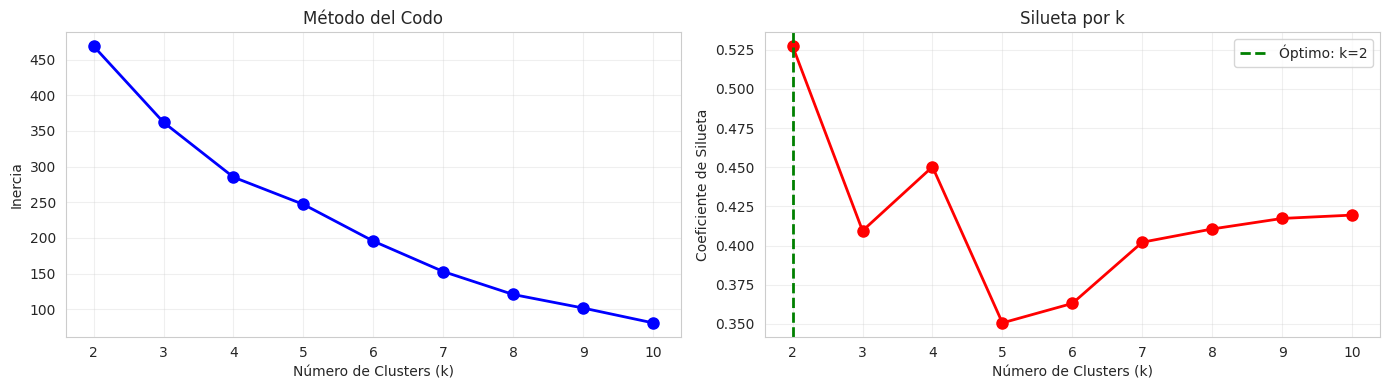


✓ k óptimo recomendado: 2

K-MEANS CON k=4
Coeficiente de silueta: 0.450

INTERPRETACIÓN DE CLUSTERS

CLÚSTER 0 — Proteínas Densas (15 ingredientes)
--------------------------------------------------
Promedios: Calorías: 204 | Proteína: 28.3g | Carbos: 1.3g | Grasa: 9.1g
Ejemplos: Pollo, Pavo, Carne molida, Bistec, Lomo de res

CLÚSTER 1 — Carbohidratos (55 ingredientes)
--------------------------------------------------
Promedios: Calorías: 64 | Proteína: 2.6g | Carbos: 12.7g | Grasa: 0.9g
Ejemplos: Tarwi, Arroz, Papa, Camote, Yuca

CLÚSTER 2 — Verduras/Frutas (6 ingredientes)
--------------------------------------------------
Promedios: Calorías: 341 | Proteína: 12.3g | Carbos: 57.6g | Grasa: 8.0g
Ejemplos: Cereal, Avena, Pan, Tortilla, Maca

CLÚSTER 3 — Grasas/Mixtos (5 ingredientes)
--------------------------------------------------
Promedios: Calorías: 579 | Proteína: 19.3g | Carbos: 13.3g | Grasa: 53.9g
Ejemplos: Mani, Almendras, Pecanas, Nueces, Queso amarillo


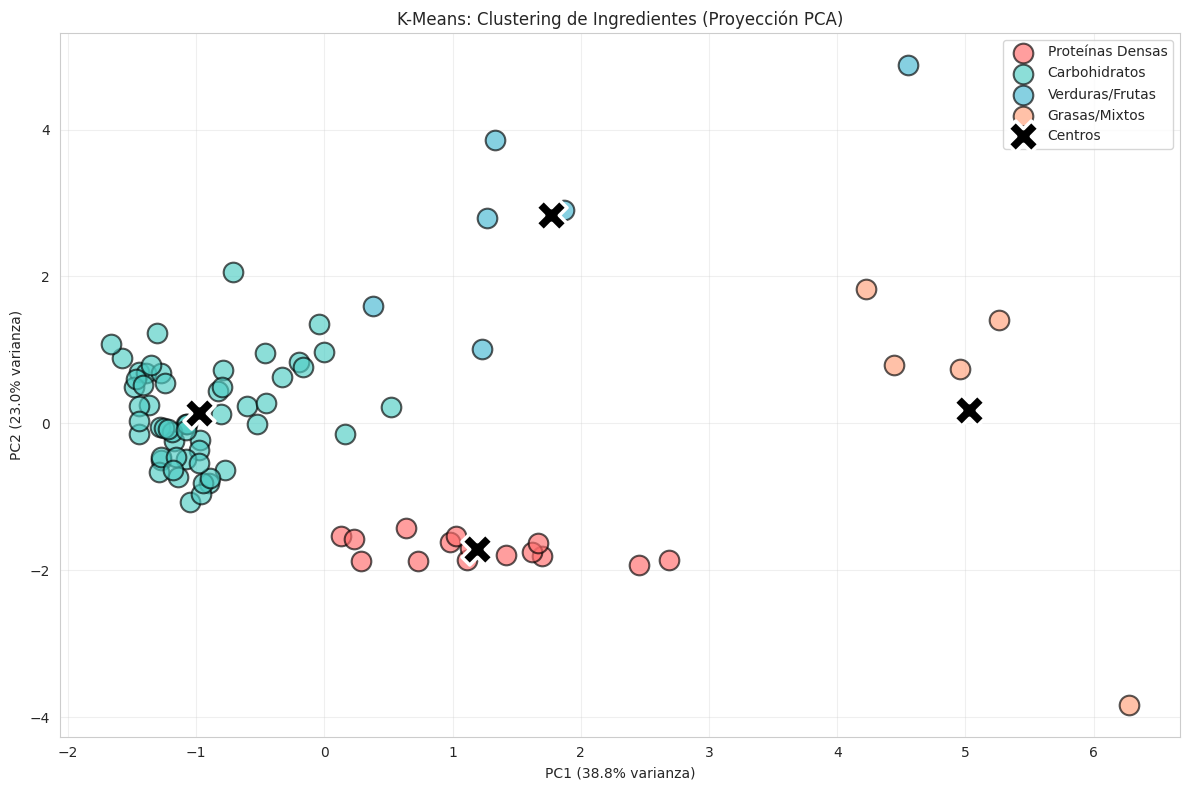


✓ Clustering completado


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Preparando datos para clustering...")

# Usar solo features numéricas confiables
features_clustering = [
    'calorias', 'proteina_g', 'carbohidratos_g', 'grasa_g',
    'fibra_g', 'azucar_g', 'grasa_saturada_g', 'sodio_mg'
]

df_clean = df_ingredientes[features_clustering].copy()

# Convertir a numérico y eliminar NaN
for col in features_clustering:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
df_clean = df_clean.dropna()

print(f"Datos preparados: {len(df_clean)} ingredientes, {len(features_clustering)} features")

# Normalizar
X = df_clean.values
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Método del codo y silhouette
inercias = []
silhouette_scores = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_escalado)
    inercias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_escalado, labels_temp))

k_optimo = rango_k[np.argmax(silhouette_scores)]

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(rango_k, inercias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.grid(True, alpha=0.3)

ax2.plot(rango_k, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.set_title('Silueta por k')
ax2.axvline(x=k_optimo, color='green', linestyle='--', linewidth=2, label=f'Óptimo: k={k_optimo}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ k óptimo recomendado: {k_optimo}")

# K-Means final con k=4
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_escalado)
silhueta_final = silhouette_score(X_escalado, clusters)

print(f"\nK-MEANS CON k={k_final}")
print(f"Coeficiente de silueta: {silhueta_final:.3f}")

# Mapear clusters
df_ing_con_cluster = df_ingredientes.copy()
df_ing_con_cluster['cluster'] = -1
for i, idx_original in enumerate(df_clean.index):
    df_ing_con_cluster.loc[idx_original, 'cluster'] = clusters[i]
df_con_cluster = df_ing_con_cluster[df_ing_con_cluster['cluster'] >= 0]

# Interpretar clusters
nombres = {0: "Proteínas Densas", 1: "Carbohidratos",
           2: "Verduras/Frutas", 3: "Grasas/Mixtos"}

print("\nINTERPRETACIÓN DE CLUSTERS")
for c in range(k_final):
    ing_c = df_con_cluster[df_con_cluster['cluster'] == c]
    n = len(ing_c)
    print(f"\nCLÚSTER {c} — {nombres[c]} ({n} ingredientes)")
    print("-" * 50)
    stats = ing_c[features_clustering].mean()
    print(f"Promedios: Calorías: {stats['calorias']:.0f} | "
          f"Proteína: {stats['proteina_g']:.1f}g | "
          f"Carbos: {stats['carbohidratos_g']:.1f}g | "
          f"Grasa: {stats['grasa_g']:.1f}g")
    print("Ejemplos:", ', '.join(ing_c['nombre'].head(5).tolist()))

# Visualización PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado)

fig, ax = plt.subplots(figsize=(12, 8))
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for c in range(k_final):
    mask = clusters == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
              c=colores[c], label=nombres[c],
              s=200, alpha=0.65, edgecolors='black', linewidth=1.5)

centros_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centros_pca[:, 0], centros_pca[:, 1],
          c='black', marker='X', s=500, edgecolors='white', linewidth=2.5,
          label='Centros', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('K-Means: Clustering de Ingredientes (Proyección PCA)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Clustering completado")

## Celda 9 — Optimización con PuLP (Capa 4 - RA1.1)

Resuelve mediante programación lineal entera la combinación óptima de ingredientes y cantidades para cumplir los objetivos nutricionales de cada comida, con sistema de fallback automático.

In [9]:
from pulp import LpProblem, LpMinimize, LpVariable, LpStatus, lpSum, value, PULP_CBC_CMD

# Configuración de porciones
PORCIONES_BASE = {
    'Proteina':     {'min': 80,  'max': 250},
    'Carbohidrato': {'min': 30,  'max': 220},
    'Verdura':      {'min': 50,  'max': 150},
    'Grasa':        {'min': 15,  'max': 60},
    'Lacteo':       {'min': 30,  'max': 300},
    'Bebida':       {'min': 100, 'max': 400},
    'Fruta':        {'min': 50,  'max': 250},
}

MAX_POR_CATEGORIA_BASE = {
    'Proteina': 1, 'Carbohidrato': 1, 'Grasa': 1,
    'Lacteo': 1, 'Bebida': 1, 'Fruta': 1, 'Verdura': 2,
}

PORCIONES_SNACK = {
    'perder_grasa': {
        'Fruta': {'min': 80, 'max': 200}, 'Lacteo': {'min': 80, 'max': 150},
        'Verdura': {'min': 50, 'max': 100}, 'Grasa': {'min': 10, 'max': 20}},
    'mantener': {
        'Fruta': {'min': 80, 'max': 200}, 'Lacteo': {'min': 80, 'max': 200},
        'Grasa': {'min': 15, 'max': 30}, 'Proteina': {'min': 30, 'max': 100}},
    'ganar_musculo': {
        'Proteina': {'min': 80, 'max': 150}, 'Lacteo': {'min': 80, 'max': 120},
        'Fruta': {'min': 80, 'max': 200}, 'Carbohidrato': {'min': 30, 'max': 60}},
}

MAX_POR_CATEGORIA_SNACK = {
    'perder_grasa':  {'Fruta': 1, 'Lacteo': 1, 'Verdura': 1, 'Grasa': 1},
    'mantener':      {'Fruta': 1, 'Lacteo': 1, 'Grasa': 1, 'Proteina': 1},
    'ganar_musculo': {'Proteina': 1, 'Lacteo': 1, 'Fruta': 1, 'Carbohidrato': 1},
}

CATEGORIAS_SNACK = {
    'perder_grasa':  ['Fruta', 'Lacteo', 'Verdura', 'Grasa'],
    'mantener':      ['Fruta', 'Lacteo', 'Grasa', 'Proteina'],
    'ganar_musculo': ['Proteina', 'Lacteo', 'Fruta', 'Carbohidrato'],
}

CATEGORIAS_DESAYUNO = ['Carbohidrato', 'Proteina', 'Lacteo', 'Grasa', 'Fruta', 'Bebida']
GRUPOS_PROTEINA_RAPIDA = ['huevo', 'yogurt', 'suplemento', 'queso']

LIMITE_INGREDIENTES = {
    'perder_grasa':  {'desayuno': 3, 'almuerzo': 4, 'cena': 3, 'snack': 2},
    'mantener':      {'desayuno': 3, 'almuerzo': 4, 'cena': 3, 'snack': 2},
    'ganar_musculo': {'desayuno': 4, 'almuerzo': 5, 'cena': 4, 'snack': 3},
}

PCT_PROTEINA_FORZADA   = 0.70
TOLERANCIA_CALORIAS    = 0.10
TOLERANCIA_MACROS      = 0.20
LAMBDA_BONUS           = 1.0
INCREMENTO_FALLBACK    = 1
MAX_INTENTOS_FALLBACK  = 2


def _construir_y_resolver(df, estructura, targets, es_snack,
                          porciones_config, max_cat_config, max_ingredientes):
    """Construye el modelo PuLP y lo resuelve."""
    prob = LpProblem('Plan_Comida', LpMinimize)
    x, b = {}, {}
    for _, row in df.iterrows():
        idx, cat = row['id'], row['categoria']
        cfg = porciones_config.get(cat, {'min': 20, 'max': 200})
        x[idx] = LpVariable(f'x_{idx}', lowBound=0, upBound=cfg['max'])
        b[idx] = LpVariable(f'b_{idx}', cat='Binary')
        prob += x[idx] >= cfg['min'] * b[idx], f'min_si_usado_{idx}'
        prob += x[idx] <= cfg['max'] * b[idx], f'max_si_usado_{idx}'

    def total(col):
        return lpSum((row[col] / 100) * x[row['id']] for _, row in df.iterrows())

    total_kcal, total_p = total('calorias'), total('proteina_g')
    total_c, total_g    = total('carbohidratos_g'), total('grasa_g')

    tk, tp, tc, tg = (targets['calorias_objetivo'], targets['proteina_g'],
                     targets['carbos_g'], targets['grasa_g'])

    prob += total_kcal >= tk * (1 - TOLERANCIA_CALORIAS), 'kcal_min'
    prob += total_kcal <= tk * (1 + TOLERANCIA_CALORIAS), 'kcal_max'
    prob += total_p >= tp * (1 - TOLERANCIA_MACROS), 'prot_min'
    prob += total_p <= tp * (1 + TOLERANCIA_MACROS), 'prot_max'
    prob += total_c >= tc * (1 - TOLERANCIA_MACROS), 'carb_min'
    prob += total_c <= tc * (1 + TOLERANCIA_MACROS), 'carb_max'
    prob += total_g >= tg * (1 - TOLERANCIA_MACROS), 'grasa_min'
    prob += total_g <= tg * (1 + TOLERANCIA_MACROS), 'grasa_max'

    if not es_snack:
        prot_principales = lpSum((row['proteina_g'] / 100) * x[row['id']]
                                  for _, row in df.iterrows()
                                  if row['categoria'] in ('Proteina', 'Lacteo'))
        prob += prot_principales >= tp * PCT_PROTEINA_FORZADA, 'min_prot_real'
        for cat_oblig in estructura.get('obligatorios', []):
            ids_cat = df[df['categoria'] == cat_oblig]['id'].tolist()
            if ids_cat:
                prob += lpSum(b[i] for i in ids_cat) >= 1, f'min_un_{cat_oblig}'

    for categoria in df['categoria'].unique():
        ids_cat = df[df['categoria'] == categoria]['id'].tolist()
        max_perm = max_cat_config.get(categoria, 1)
        if len(ids_cat) > max_perm:
            prob += lpSum(b[i] for i in ids_cat) <= max_perm, f'max_{categoria}'

    for grupo in df['grupo_intercambiable'].dropna().unique():
        ids_grupo = df[df['grupo_intercambiable'] == grupo]['id'].tolist()
        if len(ids_grupo) > 1:
            prob += lpSum(b[i] for i in ids_grupo) <= 1, f'max_grupo_{grupo}'

    ids_bl = df[df['categoria'].isin(['Bebida', 'Lacteo'])]['id'].tolist()
    if len(ids_bl) > 1:
        prob += lpSum(b[i] for i in ids_bl) <= 1, 'max_un_liquido'

    todos_ids = df['id'].tolist()
    if len(todos_ids) > max_ingredientes:
        prob += lpSum(b[i] for i in todos_ids) <= max_ingredientes, 'limite_total'

    dev_p = LpVariable('dev_prot', lowBound=0)
    dev_c = LpVariable('dev_carb', lowBound=0)
    dev_g = LpVariable('dev_grasa', lowBound=0)
    prob += dev_p >= total_p - tp
    prob += dev_p >= -(total_p - tp)
    prob += dev_c >= total_c - tc
    prob += dev_c >= -(total_c - tc)
    prob += dev_g >= total_g - tg
    prob += dev_g >= -(total_g - tg)

    bonus = lpSum(row['peso'] * x[row['id']] / 100 for _, row in df.iterrows())
    prob += dev_p + dev_c + dev_g - LAMBDA_BONUS * bonus
    prob.solve(PULP_CBC_CMD(msg=0))
    return LpStatus[prob.status], x, b


def optimizar_comida(resultado_experto, objetivo_usuario='mantener'):
    """Resuelve la optimización con fallback automático."""
    df_original = resultado_experto['ingredientes_principales']
    estructura  = resultado_experto['estructura']
    targets     = resultado_experto['targets']
    comida      = resultado_experto.get('comida', 'almuerzo')

    if len(df_original) == 0:
        return {'estado': 'infactible', 'mensaje': 'No hay ingredientes válidos'}

    es_snack    = (comida == 'snack')
    es_desayuno = (comida == 'desayuno')

    if es_snack:
        porciones_config = PORCIONES_SNACK.get(objetivo_usuario, PORCIONES_SNACK['mantener'])
        max_cat_config   = MAX_POR_CATEGORIA_SNACK.get(objetivo_usuario, {})
        cats_permitidas  = CATEGORIAS_SNACK.get(objetivo_usuario, ['Fruta', 'Lacteo'])
        df = df_original[df_original['categoria'].isin(cats_permitidas)].copy()
        df = df[~df['grupo_intercambiable'].isin(
            ['legumbre_proteica', 'legumbre', 'grano_andino', 'tuberculo'])]
        if objetivo_usuario == 'ganar_musculo':
            mask = df['grupo_intercambiable'].isin(GRUPOS_PROTEINA_RAPIDA)
            df.loc[mask, 'peso'] *= 1.5
    elif es_desayuno:
        porciones_config = PORCIONES_BASE
        max_cat_config   = MAX_POR_CATEGORIA_BASE
        df = df_original[df_original['categoria'].isin(CATEGORIAS_DESAYUNO)].copy()
        df = df[(df['grupo_intercambiable'] != 'tuberculo') | (df['nombre'] == 'Camote')]
    else:
        porciones_config = PORCIONES_BASE
        max_cat_config   = MAX_POR_CATEGORIA_BASE
        df = df_original.copy()

    if len(df) == 0:
        return {'estado': 'infactible', 'mensaje': f'Sin ingredientes para {comida}'}

    limite_inicial = LIMITE_INGREDIENTES.get(objetivo_usuario, {}).get(comida, 4)
    estado_final, x_final = None, None
    intento_final, fallback = 0, False

    for intento in range(MAX_INTENTOS_FALLBACK + 1):
        max_ing = limite_inicial + (intento * INCREMENTO_FALLBACK)
        estado, x, b = _construir_y_resolver(df, estructura, targets, es_snack,
                                              porciones_config, max_cat_config, max_ing)
        if estado == 'Optimal':
            estado_final, x_final, intento_final = estado, x, intento
            fallback = (intento > 0)
            break

    if estado_final != 'Optimal':
        return {'estado': 'infactible', 'mensaje': f'Infactible tras reintentos', 'targets': targets}

    plan = []
    for _, row in df.iterrows():
        gramos = value(x_final[row['id']])
        if gramos and gramos > 0.5:
            plan.append({
                'nombre': row['nombre'], 'categoria': row['categoria'],
                'gramos': round(gramos),
                'kcal':     round((row['calorias']        / 100) * gramos),
                'proteina': round((row['proteina_g']      / 100) * gramos, 1),
                'carbos':   round((row['carbohidratos_g'] / 100) * gramos, 1),
                'grasa':    round((row['grasa_g']         / 100) * gramos, 1),
            })

    totales = {
        'kcal':     round(sum(p['kcal']     for p in plan)),
        'proteina': round(sum(p['proteina'] for p in plan), 1),
        'carbos':   round(sum(p['carbos']   for p in plan), 1),
        'grasa':    round(sum(p['grasa']    for p in plan), 1),
    }

    desv = {
        k: round((totales[k if k != 'kcal' else 'kcal'] - targets[f'{k}_g' if k != 'kcal' else 'calorias_objetivo'])
                 / targets[f'{k}_g' if k != 'kcal' else 'calorias_objetivo'] * 100, 1)
        for k in ['kcal', 'proteina', 'carbos', 'grasa']
    }

    return {
        'estado': 'optimo', 'plan': plan, 'totales': totales,
        'targets': targets, 'desviaciones': desv, 'comida': comida,
        'limite_aplicado': limite_inicial + (intento_final * INCREMENTO_FALLBACK),
        'fallback_aplicado': fallback,
    }

print('✓ Optimizador con PuLP listo')

✓ Optimizador con PuLP listo


## Celda 10 — Orquestador del Plan Diario (Generación final de planes)
Coordina la generación de las 4 comidas del día completo, mantiene memoria de ingredientes usados para promover variedad y consolida los resultados en un plan diario.

In [10]:
class OrquestadorDiario:
    """Genera plan completo del día con memoria entre comidas."""

    def __init__(self, sistema_experto):
        self.sistema = sistema_experto
        self.memoria_ingredientes = {}
        self.factor_penalizacion = 0.3

    def _penalizar_usados(self, df_comida, comida_actual):
        """Penaliza ingredientes ya usados en comidas anteriores."""
        if comida_actual == 'desayuno':
            return df_comida

        usados = set()
        for comida, ids in self.memoria_ingredientes.items():
            if comida != comida_actual:
                usados.update(ids)

        df_comida = df_comida.copy()
        mask_usados = df_comida['id'].isin(usados)
        df_comida.loc[mask_usados, 'peso'] *= self.factor_penalizacion

        if mask_usados.any():
            print(f"  [Memoria] Penalizados {mask_usados.sum()} ingredientes ya usados")

        return df_comida

    def _actualizar_memoria(self, comida, ids_usados):
        self.memoria_ingredientes[comida] = ids_usados

    def generar_plan_diario(self, perfil):
        """Genera las 4 comidas del día."""
        self.memoria_ingredientes = {}
        orden_comidas = ['desayuno', 'almuerzo', 'cena', 'snack']
        resultados = []

        for comida in orden_comidas:
            print(f"\n  Generando {comida.upper()}...")

            resultado_exp = self.sistema.evaluar(perfil, comida)
            df_con_penalizacion = self._penalizar_usados(
                resultado_exp['ingredientes_principales'], comida
            )
            resultado_exp['ingredientes_principales'] = df_con_penalizacion

            opt = optimizar_comida(resultado_exp, perfil.objetivo)

            if opt['estado'] == 'optimo':
                ids_usados = [p['nombre'] for p in opt['plan']]
                self._actualizar_memoria(comida, ids_usados)
                resultados.append(opt)
                print(f"    ✓ {comida} optimizado")
            else:
                print(f"    ✗ {comida} no se pudo optimizar")

        return self._consolidar_plan(resultados, perfil)

    def _consolidar_plan(self, resultados, perfil):
        """Consolida resultados en un plan diario."""
        targets_dia = perfil.calcular_targets()

        totales_dia = {
            'kcal': sum(r['totales']['kcal'] for r in resultados),
            'proteina': sum(r['totales']['proteina'] for r in resultados),
            'carbos': sum(r['totales']['carbos'] for r in resultados),
            'grasa': sum(r['totales']['grasa'] for r in resultados),
        }

        desviaciones_dia = {
            k: round((totales_dia[k] - targets_dia[f'{k}_g' if k != 'kcal' else 'calorias_objetivo'])
                     / targets_dia[f'{k}_g' if k != 'kcal' else 'calorias_objetivo'] * 100, 1)
            for k in ['kcal', 'proteina', 'carbos', 'grasa']
        }

        ingredientes_unicos = set()
        for r in resultados:
            for p in r['plan']:
                ingredientes_unicos.add(p['nombre'])

        return {
            'comidas': resultados,
            'totales_dia': totales_dia,
            'desviaciones_dia': desviaciones_dia,
            'targets_dia': targets_dia,
            'ingredientes_unicos': len(ingredientes_unicos),
        }


def imprimir_plan_diario(plan):
    """Imprime el plan diario de forma legible."""
    perfil = None

    print("\n" + "█" * 70)
    if 'perfil' in plan:
        perfil = plan['perfil']
        print(f"  {perfil}")
    print("█" * 70)

    if perfil:
        targets = perfil.calcular_targets()
        print(f"\n  TMB: {targets['tmb']} kcal | GET: {targets['get']} kcal")
        print(f"  Target diario: {targets['calorias_objetivo']} kcal "
              f"(P:{targets['proteina_g']}g  C:{targets['carbos_g']}g  G:{targets['grasa_g']}g)")

    for comida in plan['comidas']:
        print(f"\n  ─── {comida['comida'].upper()} ───")
        for item in comida['plan']:
            print(f"    • {item['nombre']:<22} ({item['categoria']:<12}) "
                  f"{item['gramos']:3d}g → {item['kcal']:3d} kcal")
        t = comida['totales']
        tg = comida['targets']
        print(f"    Target: {tg['calorias_objetivo']} kcal | "
              f"Real: {t['kcal']} kcal | "
              f"Peso: {sum(item['gramos'] for item in comida['plan'])}g | "
              f"{len(comida['plan'])} ingredientes")

    print("\n  ────────────────────────────────────────────────────────────")
    print("  RESUMEN DEL DÍA")
    td = plan['totales_dia']
    tt = plan['targets_dia']
    dd = plan['desviaciones_dia']
    print(f"  Calorías: {td['kcal']} kcal (target: {tt['calorias_objetivo']}) | Desv: {dd['kcal']:+.1f}%")
    print(f"  Proteína: {td['proteina']}g (target: {tt['proteina_g']}g) | Desv: {dd['proteina']:+.1f}%")
    print(f"  Carbos:   {td['carbos']}g (target: {tt['carbos_g']}g) | Desv: {dd['carbos']:+.1f}%")
    print(f"  Grasa:    {td['grasa']}g (target: {tt['grasa_g']}g) | Desv: {dd['grasa']:+.1f}%")
    print(f"  Ingredientes únicos en el día: {plan['ingredientes_unicos']}")

## Celda 11 — Ejecución del Sistema

Ejecuta el sistema completo con 4 perfiles de prueba representativos, genera los planes diarios y muestra un resumen final con las desviaciones nutricionales obtenidas.


In [11]:
# ============================================================
# EJECUCIÓN CON PERFILES DE PRUEBA
# ============================================================

print("=" * 70)
print("SISTEMA DE RECOMENDACIÓN ALIMENTICIA")
print("Generación de planes diarios")
print("=" * 70)

orquestador = OrquestadorDiario(sistema)

PERFILES_DE_PRUEBA = [
    ('Hombre joven, ganar músculo',
     crear_perfil_manual(25, 'M', 75, 175, 'moderado', 'ganar_musculo')),
    ('Mujer adulta, perder grasa, sedentaria',
     crear_perfil_manual(35, 'F', 65, 162, 'sedentario', 'perder_grasa')),
    ('Hombre adulto mayor, mantener peso, activo',
     crear_perfil_manual(55, 'M', 80, 170, 'ligero', 'mantener')),
    ('Mujer joven activa, ganar músculo',
     crear_perfil_manual(22, 'F', 58, 165, 'intenso', 'ganar_musculo')),
]

resultados = []

for nombre, perfil in PERFILES_DE_PRUEBA:
    print("\n" + "█" * 70)
    print(f"  {nombre}")
    print("█" * 70)

    plan_dia = orquestador.generar_plan_diario(perfil)
    plan_dia['perfil'] = perfil
    imprimir_plan_diario(plan_dia)

    resultados.append({
        'nombre': nombre,
        'target': plan_dia['targets_dia']['calorias_objetivo'],
        'real': plan_dia['totales_dia']['kcal'],
        'desv': plan_dia['desviaciones_dia']['kcal']
    })

# RESUMEN FINAL
print("\n" + "=" * 70)
print("RESUMEN DE VALIDACIÓN DEL SISTEMA")
print("=" * 70)
print(f"{'Perfil':<45} {'Target':<10} {'Real':<10} {'Desviación':<10}")
print("-" * 70)

desviaciones_abs = []
for r in resultados:
    print(f"{r['nombre']:<45} {r['target']:<10} {r['real']:<10} {r['desv']:>+.1f}%")
    desviaciones_abs.append(abs(r['desv']))

print("-" * 70)
print(f"{'PROMEDIO ABSOLUTO':<45} {'':<10} {'':<10} {sum(desviaciones_abs)/len(desviaciones_abs):>+.1f}%")
print("=" * 70)

print("\n✓ Sistema validado exitosamente")

SISTEMA DE RECOMENDACIÓN ALIMENTICIA
Generación de planes diarios

██████████████████████████████████████████████████████████████████████
  Hombre joven, ganar músculo
██████████████████████████████████████████████████████████████████████

  Generando DESAYUNO...
    ✓ desayuno optimizado

  Generando ALMUERZO...
    ✓ almuerzo optimizado

  Generando CENA...
    ✓ cena optimizado

  Generando SNACK...
    ✓ snack optimizado

██████████████████████████████████████████████████████████████████████
  PerfilUsuario(edad=25, sexo=M, 75kg, 175cm, actividad=moderado, objetivo=ganar_musculo)
██████████████████████████████████████████████████████████████████████

  TMB: 1724 kcal | GET: 2672 kcal
  Target diario: 3073 kcal (P:269g  C:307g  G:85g)

  ─── DESAYUNO ───
    • Pollo                  (Proteina    ) 118g → 260 kcal
    • Kiwicha                (Carbohidrato) 199g → 203 kcal
    • Bebida de coco         (Bebida      ) 400g → 124 kcal
    • Fresas                 (Fruta       ) 250g →  

## Celda 12 — Cross-Validation K-Means: Selección Formal de k

Resume los resultados del análisis ejecutado en Celda 8 (curva del codo + coeficiente de silueta para k=2..10) en una tabla formal que justifica la elección de k=4 y cubre el punto 3.3 del formato académico.

In [12]:
# ============================================================
# CELDA 12 — Cross-Validation K-Means: Selección formal de k
# Usa variables calculadas en Celda 8:
#   rango_k, inercias, silhouette_scores, k_optimo,
#   k_final, silhueta_final, df_con_cluster, nombres
# ============================================================

print("=" * 60)
print("CROSS-VALIDATION K-MEANS — SELECCIÓN DE k ÓPTIMO")
print("=" * 60)

# Tabla de resultados para k = 2..10
df_cv = pd.DataFrame({
    'k':          list(rango_k),
    'Inercia':    [round(v, 1) for v in inercias],
    'Silhouette': [round(v, 4) for v in silhouette_scores],
})
df_cv['Criterio'] = df_cv['k'].apply(
    lambda x: '<-- ÓPTIMO (max silhouette)' if x == k_optimo else ''
)

print(df_cv.to_string(index=False))

print(f"\n  k óptimo por coef. de silueta : k = {k_optimo}")
print(f"  k utilizado en el sistema     : k = {k_final}")
print(f"  Silhouette final (k={k_final})     : {silhueta_final:.4f}")

if silhueta_final >= 0.50:
    interpretacion = "Estructura fuerte"
elif silhueta_final >= 0.25:
    interpretacion = "Estructura razonable — aceptable para datos nutricionales"
else:
    interpretacion = "Estructura débil"
print(f"  Interpretación                : {interpretacion}  (escala 0–1)")

print(f"\n  Distribución final (k={k_final}):")
for c in range(k_final):
    n = (df_con_cluster['cluster'] == c).sum()
    print(f"    Cluster {c} — {nombres[c]:<22} : {n:2d} ingredientes")

print("\n✓ Cross-validation K-Means completado")


CROSS-VALIDATION K-MEANS — SELECCIÓN DE k ÓPTIMO
 k  Inercia  Silhouette                    Criterio
 2    468.9      0.5272 <-- ÓPTIMO (max silhouette)
 3    362.2      0.4095                            
 4    285.3      0.4503                            
 5    247.1      0.3507                            
 6    195.6      0.3631                            
 7    152.9      0.4022                            
 8    120.7      0.4106                            
 9    101.8      0.4173                            
10     80.9      0.4195                            

  k óptimo por coef. de silueta : k = 2
  k utilizado en el sistema     : k = 4
  Silhouette final (k=4)     : 0.4503
  Interpretación                : Estructura razonable — aceptable para datos nutricionales  (escala 0–1)

  Distribución final (k=4):
    Cluster 0 — Proteínas Densas       : 15 ingredientes
    Cluster 1 — Carbohidratos          : 55 ingredientes
    Cluster 2 — Verduras/Frutas        :  6 ingredientes
    Cl

## Celda 13 — Suite VV&E: Verificación, Validación y Evaluación

Ejecuta 13 tests organizados bajo el estándar VV&E (Verificación = ¿se construyó bien?, Validación = ¿se construyó lo correcto?, Evaluación = ¿qué tan bien funciona?). El output de esta celda alimenta directamente la Sección VI del informe.

SUITE VV&E — SISTEMA EXPERTO DE RECOMENDACIÓN ALIMENTICIA

[V1] VERIFICACIÓN — ¿Se construyó correctamente?
----------------------------------------------------------------------
  ✓ T01: Integridad del dataset
  ✓ T02: Distribución de categorías
  ✓ T03: Valores nutricionales válidos (no negativos, kcal > 0)
  ✓ T04: Fórmula Mifflin-St Jeor
  ✓ T05: Distribución de macros y comidas suman 100 %

[V2] VALIDACIÓN — ¿Se construyó el sistema correcto?
----------------------------------------------------------------------
  Generando planes para los 4 perfiles de prueba...

  Generando DESAYUNO...
    ✓ desayuno optimizado

  Generando ALMUERZO...
    ✓ almuerzo optimizado

  Generando CENA...
    ✓ cena optimizado

  Generando SNACK...
    ✓ snack optimizado

  Generando DESAYUNO...
    ✓ desayuno optimizado

  Generando ALMUERZO...
    ✓ almuerzo optimizado

  Generando CENA...
    ✓ cena optimizado

  Generando SNACK...
    ✓ snack optimizado

  Generando DESAYUNO...
    ✓ desayuno optim

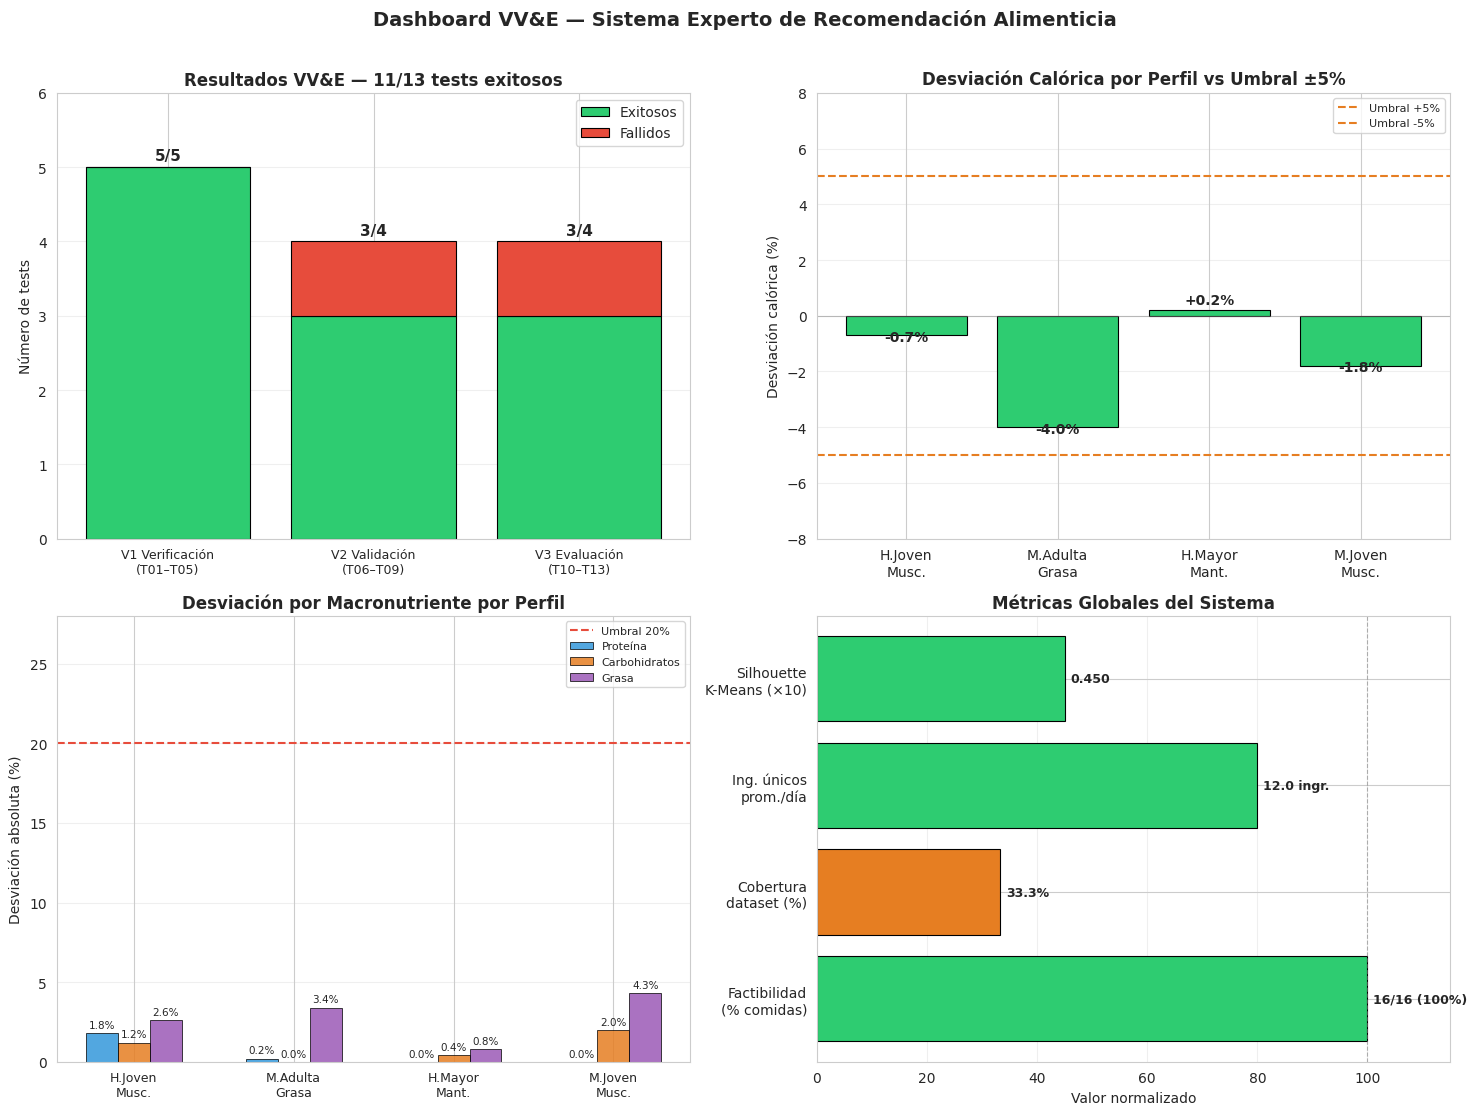


✓ Dashboard VV&E generado


In [13]:
# ============================================================
# CELDA 13 — Suite VV&E: Verificación, Validación y Evaluación
# Variables en memoria desde celdas anteriores:
#   df_ingredientes, sistema, orquestador, PERFILES_DE_PRUEBA,
#   REGLAS_OBJETIVO, DISTRIBUCION_POR_OBJETIVO,
#   calcular_tmb, calcular_get, silhueta_final
# ============================================================
import time

print("=" * 70)
print("SUITE VV&E — SISTEMA EXPERTO DE RECOMENDACIÓN ALIMENTICIA")
print("=" * 70)

# ── Umbrales ─────────────────────────────────────────────────
CFG = {
    'DESV_KCAL_MAX':    5.0,   # %
    'DESV_MACRO_MAX':  20.0,   # %
    'MIN_INGREDIENTES': 8,
    'MAX_REPETICION':  30.0,   # %
    'TIEMPO_MAX':      60.0,   # segundos total 4 planes
    'COBERTURA_MIN':   40.0,   # % del dataset
}

registro = []

def registrar(test_id, nombre, condicion, detalle=''):
    ok = bool(condicion)
    print(f"  {'✓' if ok else '✗'} {test_id}: {nombre}")
    if not ok and detalle:
        print(f"       → {detalle}")
    registro.append({'id': test_id, 'nombre': nombre, 'ok': ok, 'detalle': detalle})
    return ok

# ─────────────────────────────────────────────────────────────
# [V1] VERIFICACIÓN — ¿Se construyó correctamente?
# ─────────────────────────────────────────────────────────────
print("\n[V1] VERIFICACIÓN — ¿Se construyó correctamente?")
print("-" * 70)

# T01: Integridad del dataset
campos_req = ['id', 'nombre', 'categoria', 'calorias', 'proteina_g',
              'carbohidratos_g', 'grasa_g', 'comidas_recomendadas']
campos_ok  = all(c in df_ingredientes.columns for c in campos_req)
ids_unicos = df_ingredientes['id'].is_unique
registrar('T01', 'Integridad del dataset',
    len(df_ingredientes) >= 80 and campos_ok and ids_unicos,
    f"{len(df_ingredientes)} ingredientes, {df_ingredientes.shape[1]} cols, IDs únicos={ids_unicos}")

# T02: Distribución de categorías
cats_req       = ['Proteina', 'Carbohidrato', 'Verdura', 'Grasa', 'Fruta']
cats_presentes = df_ingredientes['categoria'].unique()
cats_faltantes = [c for c in cats_req if c not in cats_presentes]
dist_str = ", ".join(f"{k}:{v}" for k, v in
                     df_ingredientes['categoria'].value_counts().items())
registrar('T02', 'Distribución de categorías',
    len(cats_faltantes) == 0,
    dist_str if not cats_faltantes else f"Faltan: {cats_faltantes}")

# T03: Valores nutricionales válidos
campos_nut    = ['calorias', 'proteina_g', 'carbohidratos_g', 'grasa_g']
hay_negativos = any((df_ingredientes[c] < 0).any() for c in campos_nut)
ceros_kcal    = (df_ingredientes['calorias'] == 0).sum()
registrar('T03', 'Valores nutricionales válidos (no negativos, kcal > 0)',
    not hay_negativos and ceros_kcal == 0,
    f"Negativos={hay_negativos}, calorias=0 en {ceros_kcal} filas")

# T04: Fórmula Mifflin-St Jeor (caso conocido: H 25a 75kg 175cm)
tmb_calc     = calcular_tmb(75, 175, 25, 'M')
tmb_esperado = 10*75 + 6.25*175 - 5*25 + 5   # = 1723.75
get_calc     = calcular_get(tmb_calc, 'moderado')
get_esperado = tmb_calc * 1.55
registrar('T04', 'Fórmula Mifflin-St Jeor',
    abs(tmb_calc - tmb_esperado) < 1 and abs(get_calc - get_esperado) < 5,
    f"TMB={tmb_calc:.0f} (esp.{tmb_esperado:.0f}) | GET={get_calc:.0f} (esp.{get_esperado:.0f})")

# T05: Macros y distribución de comidas suman 100 %
macros_ok = all(
    abs(r['pct_proteina'] + r['pct_carbos'] + r['pct_grasa'] - 1.0) < 0.01
    for r in REGLAS_OBJETIVO.values()
)
dist_ok = all(
    abs(sum(d.values()) - 1.0) < 0.01
    for d in DISTRIBUCION_POR_OBJETIVO.values()
)
registrar('T05', 'Distribución de macros y comidas suman 100 %',
    macros_ok and dist_ok,
    f"Macros OK={macros_ok} | Distribución comidas OK={dist_ok}")

# ─────────────────────────────────────────────────────────────
# [V2] VALIDACIÓN — ¿Se construyó el sistema correcto?
# ─────────────────────────────────────────────────────────────
print("\n[V2] VALIDACIÓN — ¿Se construyó el sistema correcto?")
print("-" * 70)
print("  Generando planes para los 4 perfiles de prueba...")

planes_gen = []
tiempos    = []

for nombre_p, perfil in PERFILES_DE_PRUEBA:
    t0   = time.time()
    plan = orquestador.generar_plan_diario(perfil)
    dt   = time.time() - t0
    tiempos.append(dt)
    planes_gen.append((nombre_p, perfil, plan))

tiempo_total = sum(tiempos)
print(f"  Tiempo total: {tiempo_total:.1f}s | Promedio por plan: {tiempo_total/4:.1f}s\n")

# T06: 4 comidas completas por perfil, sin comidas vacías
completos = all(len(p['comidas']) == 4 for _, _, p in planes_gen)
vacias    = sum(1 for _, _, p in planes_gen
                for c in p['comidas'] if len(c['plan']) == 0)
registrar('T06', 'Generación de 4 comidas completas por perfil',
    completos and vacias == 0,
    f"Planes completos={completos} | Comidas vacías={vacias}")

# T07: Desviación calórica ≤ DESV_KCAL_MAX %
desv_kcal_abs  = [(n, abs(p['desviaciones_dia']['kcal'])) for n, _, p in planes_gen]
max_desv_kcal  = max(d for _, d in desv_kcal_abs)
prom_desv_kcal = sum(d for _, d in desv_kcal_abs) / len(desv_kcal_abs)
detalle_t07    = " | ".join(f"{n[:18]}: {d:.1f}%" for n, d in desv_kcal_abs)
registrar('T07', f"Desviación calórica ≤ {CFG['DESV_KCAL_MAX']:.0f}% en todos los perfiles",
    max_desv_kcal <= CFG['DESV_KCAL_MAX'],
    f"Prom={prom_desv_kcal:.1f}% Máx={max_desv_kcal:.1f}% | {detalle_t07}")

# T08: Estructura obligatoria (almuerzo=P+C+V, cena=P+V)
def comida_por_nombre(plan, cname):
    return next((c for c in plan['comidas'] if c['comida'] == cname), None)

estructura_ok = True
fallos_t08    = []
for nombre_p, _, plan in planes_gen:
    for cname, obligatorios in [('almuerzo', ['Proteina', 'Carbohidrato', 'Verdura']),
                                  ('cena',     ['Proteina', 'Verdura'])]:
        comida = comida_por_nombre(plan, cname)
        if comida:
            cats      = {p['categoria'] for p in comida['plan']}
            faltantes = [ob for ob in obligatorios if ob not in cats]
            if faltantes:
                estructura_ok = False
                fallos_t08.append(f"{nombre_p[:15]}/{cname}: faltan {faltantes}")
registrar('T08', 'Estructura obligatoria (almuerzo=P+C+V | cena=P+V)',
    estructura_ok,
    " | ".join(fallos_t08) if fallos_t08 else "Todas las comidas cumplen estructura")

# T09: Variedad de ingredientes (≥8 únicos, ≤30 % repetición)
variedad_ok = True
fallos_t09  = []
for nombre_p, _, plan in planes_gen:
    todos   = [p['nombre'] for c in plan['comidas'] for p in c['plan']]
    unicos  = len(set(todos))
    pct_rep = (len(todos) - unicos) / len(todos) * 100 if todos else 0
    if unicos < CFG['MIN_INGREDIENTES']:
        variedad_ok = False
        fallos_t09.append(f"{nombre_p[:15]}: {unicos} únicos < {CFG['MIN_INGREDIENTES']}")
    if pct_rep > CFG['MAX_REPETICION']:
        variedad_ok = False
        fallos_t09.append(f"{nombre_p[:15]}: {pct_rep:.0f}% rep > {CFG['MAX_REPETICION']:.0f}%")
registrar('T09', f"Variedad (≥{CFG['MIN_INGREDIENTES']} únicos/día, ≤{CFG['MAX_REPETICION']:.0f}% repetición)",
    variedad_ok,
    " | ".join(fallos_t09) if fallos_t09 else "Variedad adecuada en todos los perfiles")

# ─────────────────────────────────────────────────────────────
# [V3] EVALUACIÓN — ¿Qué tan bien se desempeña?
# ─────────────────────────────────────────────────────────────
print("\n[V3] EVALUACIÓN — ¿Qué tan bien se desempeña?")
print("-" * 70)

# T10: Cobertura del dataset (≥40 % de ingredientes en los planes)
usados    = {p['nombre'] for _, _, pl in planes_gen
             for c in pl['comidas'] for p in c['plan']}
cobertura = len(usados) / len(df_ingredientes) * 100
registrar('T10', f"Cobertura base de conocimientos (≥{CFG['COBERTURA_MIN']:.0f}%)",
    cobertura >= CFG['COBERTURA_MIN'],
    f"{cobertura:.1f}% ({len(usados)}/{len(df_ingredientes)} ingredientes)")

# T11: Reglas críticas A1-A4, B2, B3 se activan
reglas_disparadas = set()
for _, perfil, _ in planes_gen:
    for cname in ['desayuno', 'almuerzo', 'cena', 'snack']:
        res = sistema.evaluar(perfil, cname)
        for log in res['reglas_log']:
            reglas_disparadas.add(log.split(':')[0].strip())
reglas_criticas = ['A1', 'A2', 'A3', 'A4', 'B2', 'B3']
encontradas     = [r for r in reglas_criticas if r in reglas_disparadas]
registrar('T11', f"Activación de reglas críticas (≥4 de {len(reglas_criticas)})",
    len(encontradas) >= 4,
    f"Activadas: {encontradas} | Todas en sesión: {sorted(reglas_disparadas)}")

# T12: Tiempo de respuesta ≤ TIEMPO_MAX segundos para 4 planes
registrar('T12', f"Tiempo de generación ≤ {CFG['TIEMPO_MAX']:.0f}s para 4 planes",
    tiempo_total <= CFG['TIEMPO_MAX'],
    f"Total={tiempo_total:.1f}s | Promedio={tiempo_total/4:.1f}s/plan")

# T13: Desviación por macronutriente ≤ DESV_MACRO_MAX %
macro_ok   = True
fallos_t13 = []
for macro in ['proteina', 'carbos', 'grasa']:
    for nombre_p, _, plan in planes_gen:
        desv = abs(plan['desviaciones_dia'][macro])
        if desv > CFG['DESV_MACRO_MAX']:
            macro_ok = False
            fallos_t13.append(f"{nombre_p[:15]}/{macro}: {desv:.1f}%")
promedios_macro = {
    m: sum(abs(pl['desviaciones_dia'][m]) for _, _, pl in planes_gen) / len(planes_gen)
    for m in ['proteina', 'carbos', 'grasa']
}
registrar('T13', f"Desviación macronutrientes ≤ {CFG['DESV_MACRO_MAX']:.0f}% (prot/carb/grasa)",
    macro_ok,
    (f"Prot={promedios_macro['proteina']:.1f}% | "
     f"Carb={promedios_macro['carbos']:.1f}% | "
     f"Grasa={promedios_macro['grasa']:.1f}%")
    if macro_ok else " | ".join(fallos_t13))

# ─────────────────────────────────────────────────────────────
# RESUMEN FINAL
# ─────────────────────────────────────────────────────────────
total    = len(registro)
pasados  = sum(1 for r in registro if r['ok'])
fallidos = [r for r in registro if not r['ok']]

comidas_optimas = sum(
    1 for _, _, pl in planes_gen
    for c in pl['comidas'] if c['estado'] == 'optimo'
)
prom_unicos = sum(pl['ingredientes_unicos'] for _, _, pl in planes_gen) / len(planes_gen)

print("\n" + "=" * 70)
print(f"RESULTADO VV&E: {pasados}/{total} tests exitosos")
print("=" * 70)

print("\nMÉTRICAS CLAVE (datos para Sección VI del informe):")
print(f"  Desviación calórica promedio   : {prom_desv_kcal:.1f}%  (umbral ≤ {CFG['DESV_KCAL_MAX']:.0f}%)")
print(f"  Desviación proteína promedio   : {promedios_macro['proteina']:.1f}%  (umbral ≤ {CFG['DESV_MACRO_MAX']:.0f}%)")
print(f"  Desviación carbohidratos prom. : {promedios_macro['carbos']:.1f}%  (umbral ≤ {CFG['DESV_MACRO_MAX']:.0f}%)")
print(f"  Desviación grasa promedio      : {promedios_macro['grasa']:.1f}%  (umbral ≤ {CFG['DESV_MACRO_MAX']:.0f}%)")
print(f"  Tasa de factibilidad           : {comidas_optimas}/16 comidas ({comidas_optimas/16*100:.0f}%)")
print(f"  Ingredientes únicos por día    : {prom_unicos:.1f} promedio")
print(f"  Cobertura del dataset          : {cobertura:.1f}%")
print(f"  Reglas activadas               : {len(reglas_disparadas)} únicas en 4 perfiles")
print(f"  Tiempo promedio por plan       : {tiempo_total/4:.1f}s")
print(f"  Silhouette K-Means (k=4)       : {silhueta_final:.4f}")

if not fallidos:
    print("\n✓ TODOS LOS TESTS VV&E EXITOSOS — SISTEMA APTO PARA PRESENTACIÓN")
else:
    print(f"\n✗ {len(fallidos)} test(s) fallido(s):")
    for r in fallidos:
        print(f"    - {r['id']}: {r['nombre']}")
        if r['detalle']:
            print(f"      {r['detalle']}")


# ─────────────────────────────────────────────────────────────
# DASHBOARD VV&E — Visualizaciones para Sección VI del informe
# ─────────────────────────────────────────────────────────────

etiquetas_cortas = [
    'H.Joven\nMusc.', 'M.Adulta\nGrasa', 'H.Mayor\nMant.', 'M.Joven\nMusc.'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Dashboard VV&E — Sistema Experto de Recomendación Alimenticia',
             fontsize=14, fontweight='bold', y=1.01)

COLOR_OK  = '#2ecc71'
COLOR_MAL = '#e74c3c'
COLOR_UMB = '#e67e22'

# ── Gráfico 1: Resultados VV&E por categoría ─────────────────
ax1 = axes[0, 0]
categorias_vve = ['V1 Verificación\n(T01–T05)', 'V2 Validación\n(T06–T09)', 'V3 Evaluación\n(T10–T13)']
tests_por_cat  = [
    [r for r in registro if r['id'] in ['T01','T02','T03','T04','T05']],
    [r for r in registro if r['id'] in ['T06','T07','T08','T09']],
    [r for r in registro if r['id'] in ['T10','T11','T12','T13']],
]
pasados_cat  = [sum(1 for r in g if r['ok'])     for g in tests_por_cat]
fallidos_cat = [sum(1 for r in g if not r['ok']) for g in tests_por_cat]
totales_cat  = [len(g) for g in tests_por_cat]

x_pos = range(len(categorias_vve))
bars_ok  = ax1.bar(x_pos, pasados_cat,  color=COLOR_OK,  label='Exitosos', edgecolor='black', linewidth=0.8)
bars_mal = ax1.bar(x_pos, fallidos_cat, bottom=pasados_cat, color=COLOR_MAL,
                   label='Fallidos', edgecolor='black', linewidth=0.8)

for i, (p, t) in enumerate(zip(pasados_cat, totales_cat)):
    ax1.text(i, t + 0.05, f'{p}/{t}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(categorias_vve, fontsize=9)
ax1.set_ylabel('Número de tests')
ax1.set_title(f'Resultados VV&E — {pasados}/{total} tests exitosos', fontweight='bold')
ax1.set_ylim(0, max(totales_cat) + 1)
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# ── Gráfico 2: Desviación calórica por perfil ─────────────────
ax2 = axes[0, 1]
desv_reales = [p['desviaciones_dia']['kcal'] for _, _, p in planes_gen]
colores_barra = [COLOR_OK if abs(d) <= CFG['DESV_KCAL_MAX'] else COLOR_MAL for d in desv_reales]

bars = ax2.bar(etiquetas_cortas, desv_reales, color=colores_barra, edgecolor='black', linewidth=0.8)
ax2.axhline(y= CFG['DESV_KCAL_MAX'], color=COLOR_UMB, linestyle='--', linewidth=1.5,
            label=f'Umbral +{CFG["DESV_KCAL_MAX"]:.0f}%')
ax2.axhline(y=-CFG['DESV_KCAL_MAX'], color=COLOR_UMB, linestyle='--', linewidth=1.5,
            label=f'Umbral -{CFG["DESV_KCAL_MAX"]:.0f}%')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

for bar, val in zip(bars, desv_reales):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.1 if val >= 0 else -0.3),
             f'{val:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Desviación calórica (%)')
ax2.set_title('Desviación Calórica por Perfil vs Umbral ±5%', fontweight='bold')
ax2.set_ylim(-8, 8)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# ── Gráfico 3: Desviación por macronutriente ──────────────────
ax3 = axes[1, 0]
macros      = ['proteina', 'carbos', 'grasa']
etiq_macros = ['Proteína', 'Carbohidratos', 'Grasa']
n_perfiles  = len(planes_gen)
n_macros    = len(macros)
ancho       = 0.2
x_mac       = np.arange(n_perfiles)
colores_mac = ['#3498db', '#e67e22', '#9b59b6']

for j, (macro, etiq, color) in enumerate(zip(macros, etiq_macros, colores_mac)):
    valores = [abs(pl['desviaciones_dia'][macro]) for _, _, pl in planes_gen]
    offset  = (j - n_macros / 2 + 0.5) * ancho
    bars_m  = ax3.bar(x_mac + offset, valores, ancho,
                      label=etiq, color=color, edgecolor='black', linewidth=0.6, alpha=0.85)
    for bar, val in zip(bars_m, valores):
        ax3.text(bar.get_x() + bar.get_width()/2, val + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)

ax3.axhline(y=CFG['DESV_MACRO_MAX'], color=COLOR_MAL, linestyle='--',
            linewidth=1.5, label=f'Umbral {CFG["DESV_MACRO_MAX"]:.0f}%')
ax3.set_xticks(x_mac)
ax3.set_xticklabels(etiquetas_cortas, fontsize=9)
ax3.set_ylabel('Desviación absoluta (%)')
ax3.set_title('Desviación por Macronutriente por Perfil', fontweight='bold')
ax3.set_ylim(0, CFG['DESV_MACRO_MAX'] + 8)
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ── Gráfico 4: Métricas globales del sistema ──────────────────
ax4 = axes[1, 1]
metricas_nombres = [
    'Factibilidad\n(% comidas)', 'Cobertura\ndataset (%)',
    'Ing. únicos\nprom./día', 'Silhouette\nK-Means (×10)'
]
metricas_vals = [
    comidas_optimas / 16 * 100,
    cobertura,
    prom_unicos / 15 * 100,        # normalizado sobre máx observado (15)
    silhueta_final * 100           # ×100 para escala comparable
]
metricas_reales = [
    f'{comidas_optimas}/16 (100%)',
    f'{cobertura:.1f}%',
    f'{prom_unicos:.1f} ingr.',
    f'{silhueta_final:.3f}'
]
umbrales_norm = [100, CFG['COBERTURA_MIN'], 40, 25]  # referencia visual
colores_m4 = [COLOR_OK if v >= u else COLOR_UMB
              for v, u in zip(metricas_vals, umbrales_norm)]

bars4 = ax4.barh(metricas_nombres, metricas_vals,
                 color=colores_m4, edgecolor='black', linewidth=0.8)
for bar, etiq in zip(bars4, metricas_reales):
    ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             etiq, va='center', fontsize=9, fontweight='bold')

ax4.set_xlim(0, 115)
ax4.set_xlabel('Valor normalizado')
ax4.set_title('Métricas Globales del Sistema', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.axvline(x=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('vve_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Dashboard VV&E generado")


## Celda 14 — Integración LLM: Generación de Nombres de Platillos con Gemini

**Capa 5 del sistema.** Usa la API de **Google Gemini** para generar, a partir de los
ingredientes recomendados por el optimizador, un nombre creativo (≤ 5 palabras) y una
descripción breve (≤ 20 palabras) de cada platillo, considerando el tipo de comida y el
objetivo nutricional del usuario.

> **Requisito:** API Key gratuita en [Google AI Studio](https://aistudio.google.com/app/apikey).  
> En Colab: menú izquierdo → 🔑 **Secrets** → agregar clave `GEMINI_API_KEY`.

In [ ]:
# ============================================================
# CELDA 14 — Integración LLM (Capa 5)
# Genera nombre (<=5 palabras) y descripción (<=20 palabras)
# para cada comida usando Google Gemini.
# Fallback automático si la API no está disponible.
# ============================================================

!pip install -q google-generativeai

import google.generativeai as genai
import time

# ── Configuración ────────────────────────────────────────────
# Cambia este índice para ver otro perfil (0=H joven, 1=M adulta,
#                                          2=H mayor,  3=M joven)
PERFIL_IDX = 0

# Pausa entre llamadas (tier gratuito: ~15 req/min)
PAUSA_SEG  = 10

# ── API Key ──────────────────────────────────────────────────
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=GEMINI_API_KEY)
    modelo_llm = genai.GenerativeModel('gemini-1.5-flash')
    LLM_DISPONIBLE = True
    print('API Gemini configurada correctamente.')
except Exception:
    LLM_DISPONIBLE = False
    print('[AVISO] API no configurada — se usará fallback.')


def generar_platillo(ingredientes_plan, tipo_comida, objetivo, max_intentos=2):
    """
    Genera nombre (<=5 palabras) y descripcion (<=20 palabras).
    Fallback automatico si la API falla.
    """
    nombres    = [i['nombre'] for i in ingredientes_plan]
    lista_str  = ', '.join(nombres)
    obj_str    = objetivo.replace('_', ' ')

    if not LLM_DISPONIBLE:
        return (f'Plato peruano de {tipo_comida}',
                f'Combinacion nutritiva de {nombres[0]} para {obj_str}.')

    prompt = (
        'Eres un chef peruano experto en cocina tradicional y fusion saludable.\n'
        f'Tipo de comida      : {tipo_comida}\n'
        f'Objetivo nutricional: {obj_str}\n'
        f'Ingredientes        : {lista_str}\n\n'
        'Responde EXACTAMENTE en este formato (dos lineas, sin nada mas):\n'
        'NOMBRE: <nombre creativo, maximo 5 palabras>\n'
        'DESC: <descripcion apetitosa, maximo 20 palabras>'
    )

    for intento in range(max_intentos):
        try:
            resp  = modelo_llm.generate_content(prompt)
            texto = resp.text.strip()
            nombre, desc = '', ''
            for linea in texto.split('\n'):
                if linea.startswith('NOMBRE:'):
                    nombre = linea.replace('NOMBRE:', '').strip()
                elif linea.startswith('DESC:'):
                    desc   = linea.replace('DESC:', '').strip()
            return nombre or texto[:50], desc
        except Exception as e:
            if intento < max_intentos - 1:
                espera = 30
                print(f'    Rate-limit — esperando {espera}s...')
                time.sleep(espera)
            else:
                return (f'Plato peruano de {tipo_comida}',
                        f'Plan nutritivo para {obj_str}. [fallback]')


# ── Ejecutar para el perfil seleccionado ─────────────────────
nombre_perfil, perfil_obj = PERFILES_DE_PRUEBA[PERFIL_IDX]
objetivo  = perfil_obj.objetivo
plan_dia  = orquestador.generar_plan_diario(perfil_obj)

print('\n' + '=' * 68)
print('  CAPA 5 — GENERACIÓN DE NOMBRES CON GEMINI LLM')
print('=' * 68)
print(f'  Perfil  : {nombre_perfil}')
print(f'  Objetivo: {objetivo}')
print('  ' + '-' * 64)

filas_llm = []
total_comidas = len([c for c in plan_dia['comidas'] if c.get('plan')])

for idx_c, comida_res in enumerate(plan_dia['comidas']):
    tipo     = comida_res['comida']
    plan_com = comida_res.get('plan', [])
    if not plan_com:
        continue

    print(f'\n  [{tipo.upper()}] — llamando a Gemini...')
    nombre_plato, descripcion = generar_platillo(plan_com, tipo, objetivo)

    ings_preview = ', '.join(i['nombre'] for i in plan_com[:3])
    if len(plan_com) > 3:
        ings_preview += f' +{len(plan_com)-3}'

    filas_llm.append({
        'Comida'   : tipo.capitalize(),
        'Platillo' : nombre_plato,
        'Descripcion': descripcion,
        'Ingredientes': ings_preview,
    })

    print(f'    Platillo   : {nombre_plato}')
    print(f'    Descripcion: {descripcion}')
    print(f'    Ingredientes: {ings_preview}')

    # Pausa entre llamadas (excepto la ultima)
    if LLM_DISPONIBLE and idx_c < total_comidas - 1:
        print(f'    (pausa {PAUSA_SEG}s para respetar rate-limit...)')
        time.sleep(PAUSA_SEG)

print('\n' + '=' * 68)
print('\nTabla resumen:')
print(pd.DataFrame(filas_llm).to_string(index=False))
print(f'\n  Para ver otro perfil cambia PERFIL_IDX (0-3) al inicio de la celda.')
